# TP 3: From sequential data to portfolio selection
## Numerical processing of financial data APM 50442 EP

Matthieu Garcin

# Import the data

We're going to work with the same dataset as in TP2, that a universe of stock of size greater than 10. It can be stocks from the same geographic area, for example a selection of stocks from S&P 500 index or CAC 40 index.

We recall that for French stocks (along with their identifier in yahoo finance) can be found in [Euronext website](https://live.euronext.com/en/product/indices/FR0003500008-XPAR#index-composition):


* Accor (AC.PA)
* Air liquide (AI.PA)
* Airbus (AIR.PA)
* Bouygues (EN.PA)
* Danone (BN.PA)
* Engie (ENGI.PA)
* LVMH (MC.PA)
* Michelin (ML.PA)
* Orange (ORA.PA)
* Société générale (GLE.PA)
* Thales (HO.PA)
* BNP Paribas (BNP.PA)
* ...


We import first the prices, the same way as in TP2.

## Prices with yfinance

In [ ]:
import numpy as np
import math
import matplotlib.pyplot as plt

# Import the yfinance package
#(the first two following lines are to be executed if the current version does not contain "adjusted close"; it may require to restart the session if working in Google Colab)
!pip uninstall yfinance -y --quiet
!pip install yfinance==0.2.50 --quiet
import yfinance as yf
print(yf.__version__)

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 102.2/102.2 kB 2.1 MB/s eta 0:00:00
0.2.50


In [ ]:
start_date = '2005-01-01'
end_date = '2024-12-31'
tickers_list = ['AI.PA', 'AIR.PA', 'EN.PA', 'BN.PA', 'ENGI.PA', 'MC.PA', 'ML.PA', 'ORA.PA', 'GLE.PA', 'HO.PA', 'BNP.PA']

data_stocks = yf.download(tickers=tickers_list, start=start_date, end=end_date)
print("data_stocks shape: ", data_stocks.shape)
data_stocks.head()

[*********************100%***********************]  11 of 11 completed


data_stocks shape:  (5120, 66)


Price       Adj Close                                                        \
Ticker          AI.PA     AIR.PA      BN.PA     BNP.PA      EN.PA   ENGI.PA   
Date                                                                          
2005-01-03  17.766739  15.722153  18.414463  18.615356  11.788531  6.246168   
2005-01-04  17.766739  15.430459  18.521206  18.754019  11.877550  6.220778   
2005-01-05  17.571495  15.299199  18.387774  18.650024  11.761138  6.236648   
2005-01-06  17.623564  15.751320  18.494520  18.927347  10.353912  6.268385   
2005-01-07  17.740705  15.984676  18.654648  19.135340  11.256520  6.262039   

Price                                                  ...   Volume           \
Ticker         GLE.PA      HO.PA      MC.PA     ML.PA  ...   AIR.PA    BN.PA   
Date                                                   ...                     
2005-01-03  31.171288  22.640800  38.464314  6.238788  ...  1111249  1924322   
2005-01-04  31.525980  22.589775  38.260437  6.271253  ...  2656182  2301828   
2005-01-05  31.213013  22.513248  37.682785  6.084246  ...  2475166  1834826   
2005-01-06  31.797220  22.781111  37.818707  6.199826  ...  2603453  1499225   
2005-01-07  32.527462  22.404823  38.090534  6.105022  ...  3104359  1825031   

Price                                                                     \
Ticker       BNP.PA    EN.PA  ENGI.PA   GLE.PA   HO.PA    MC.PA    ML.PA   
Date                                                                       
2005-01-03  1788906   502181  3833200  1337598  344190   667503  2138177   
2005-01-04  2836740  2687127  4197900  1767057  406431   715871  2680428   
2005-01-05  2996281  1541074  4553900  1609361  402457  1362790  4095866   
2005-01-06  3728296  2501159  3731700  2564635  656486   885310  3757668   
2005-01-07  5603699  3470801  4065500  4359361  937855  1165939  2561426   

Price                
Ticker       ORA.PA  
Date                 
2005-01-03  6627852  
2005-01-04  7310216  
2005-01-05  6048282  
2005-01-06  8714459  
2005-01-07  8011800  

[5 rows x 66 columns]

Let's display the price (adjusted close) of all the stocks.

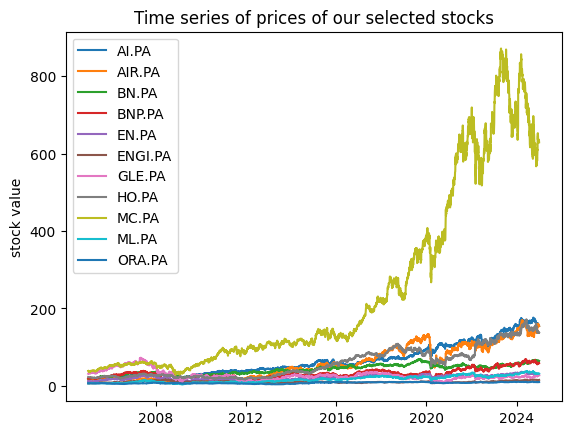

In [ ]:
for ticker in data_stocks['Adj Close'].columns:
    plt.plot(data_stocks['Adj Close'].index, data_stocks['Adj Close'][ticker], label=ticker)
plt.title("Time series of prices of our selected stocks")
plt.ylabel("stock value")
plt.grid(False)
plt.legend()
plt.show()

## Prices with Stooq

If an error occurs with yfinance...

But impossible to download French stocks. So, let's work with:
* Nvidia (NVDA)
* Apple (AAPL)
* Microsoft (MSFT)
* Amazon (AMZN)
* Alphabet (GOOGL)
* Meta (META)
* Tesla (TSLA)
* Walmart (WMT)

In [1]:
import pandas_datareader.data as web
import pandas as pd

start_date = '2005-01-01'
end_date = '2024-12-31'
tickers_list = ['NVDA','AAPL','MSFT','AMZN','GOOGL','META','TSLA','WMT']
columns_needed = ['Open', 'High', 'Low', 'Close', 'Volume']

data_by_coltype = {col: [] for col in columns_needed}

for ticker in tickers_list:
    try:
        df = web.DataReader(ticker, 'stooq')
        df = df.sort_index()  # sort the dates

        # Rename "Close" in "Adj Close"
        df = df.rename(columns={'Close': 'Adj Close'})
        df['Ticker'] = ticker

        for col in columns_needed:
            col_name = 'Adj Close' if col == 'Close' else col
            series = df[[col_name]].copy()
            series.columns = [ticker]
            data_by_coltype[col].append(series)
    except Exception as e:
        print(f"Erreur pour {ticker}: {e}")

# Concatenate and create MultiIndex
final_dfs = []
for col in columns_needed:
    dfs = data_by_coltype[col]
    if dfs:
        col_df = pd.concat(dfs, axis=1)
        col_df.columns = pd.MultiIndex.from_product([[col if col != 'Close' else 'Adj Close'], col_df.columns])
        final_dfs.append(col_df)

data_stocks = pd.concat(final_dfs, axis=1)

print(data_stocks.head())

               Open                                                        \
               NVDA     AAPL     MSFT     AMZN     GOOGL    META     TSLA   
Date                                                                        
2021-02-01  13.0206  130.202  227.207  162.118   91.8962  259.52  271.430   
2021-02-02  13.3651  132.128  233.254  169.000   95.3110  264.00  281.560   
2021-02-03  13.6018  132.156  231.574  171.251  102.9070  265.62  292.340   
2021-02-04  13.4968  132.689  234.553  166.500  102.6590  267.01  285.000   
2021-02-05  13.6907  133.906  234.132  165.950  102.6060  266.80  281.667   

                        High           ... Adj Close              Volume  \
                WMT     NVDA     AAPL  ...      TSLA      WMT       NVDA   
Date                                   ...                                 
2021-02-01  44.8353  13.2373  131.784  ...   279.937  44.3143  217755575   
2021-02-02  44.4707  13.5378  132.699  ...   290.930  44.7903  220997747   
202

## Dataframe of price returns
Like in TP2, we create a DataFrame containing the price returns.

                NVDA      AAPL      MSFT      AMZN     GOOGL      META  \
2021-02-02  0.024198  0.006326 -0.000591  0.011104  0.013761  0.019350   
2021-02-03 -0.001923 -0.007785  0.014561 -0.019959  0.072823 -0.001610   
2021-02-04  0.009921  0.025825 -0.004117  0.005573 -0.002545 -0.000600   
2021-02-05 -0.005422 -0.003058  0.000787  0.006352  0.017134  0.006042   
2021-02-08  0.062382  0.001087  0.001132 -0.008717 -0.002056 -0.005670   

                TSLA       WMT  
2021-02-02  0.039270  0.010741  
2021-02-03 -0.020737  0.003036  
2021-02-04 -0.005500  0.009431  
2021-02-05  0.002637  0.012856  
2021-02-08  0.013130  0.004681  


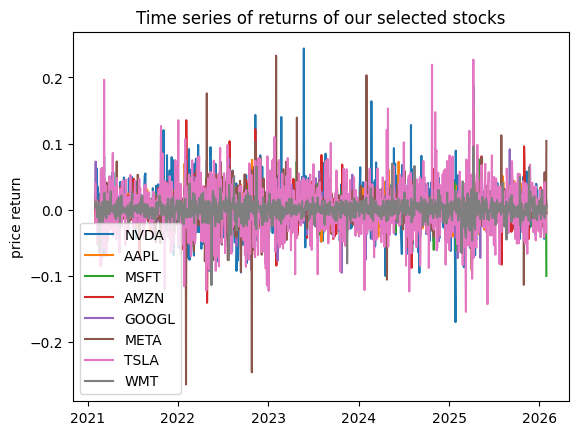

In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

dates = np.array(data_stocks.index)
returns_df = pd.DataFrame(index = dates[1:]) # We copy the dates and remove the first line

for ticker in data_stocks['Adj Close'].columns:  # type: ignore
    values = np.array(data_stocks['Adj Close'][ticker])
    returns = (values[1:] / values[:-1])-1
    returns_df[ticker] = returns

print(returns_df.head())

# Graph
for ticker in returns_df.columns:
    plt.plot(returns_df.index, returns_df[ticker], label=ticker)
#plt.plot(data_stocks['Adj Close'])
plt.title("Time series of returns of our selected stocks")
plt.ylabel("price return")
plt.grid(False)
plt.legend()
plt.show()

# Markowitz portfolio (Q1)

**Question 1:** Create a portfolio following Markowitz approach. For a given estimation set, we must be able to provide a vector of weights.

* **1.a/** Write a function returning, for a given range of dates, the covariance matrix of price returns.

In [17]:
def calc_cov(dataframe_returns, start_date, end_date):
    # Filter the dataset according to the dates
    dataframe_returns_filtered = dataframe_returns.loc[start_date:end_date]
    
    # Calculate annualized covariance matrix
    covariance_matrix = dataframe_returns_filtered.cov() * 252
    
    return covariance_matrix

covariance_matrix = calc_cov(returns_df, '2012-01-01', '2025-12-31')
print(covariance_matrix)

            NVDA      AAPL      MSFT      AMZN     GOOGL      META      TSLA  \
NVDA    0.274053  0.075446  0.084923  0.102590  0.085817  0.113612  0.150162   
AAPL    0.075446  0.076762  0.045091  0.054637  0.049935  0.058546  0.083881   
MSFT    0.084923  0.045091  0.065802  0.059043  0.051139  0.066156  0.065925   
AMZN    0.102590  0.054637  0.059043  0.123759  0.067336  0.091912  0.095819   
GOOGL   0.085817  0.049935  0.051139  0.067336  0.096511  0.075954  0.078247   
META    0.113612  0.058546  0.066156  0.091912  0.075954  0.189258  0.091555   
TSLA    0.150162  0.083881  0.065925  0.095819  0.078247  0.091555  0.368094   
WMT     0.013505  0.016892  0.013421  0.017967  0.012634  0.017589  0.022647   
market  0.112514  0.057649  0.056437  0.076633  0.064697  0.088073  0.119541   

             WMT    market  
NVDA    0.013505  0.112514  
AAPL    0.016892  0.057649  
MSFT    0.013421  0.056437  
AMZN    0.017967  0.076633  
GOOGL   0.012634  0.064697  
META    0.017589  0.08807

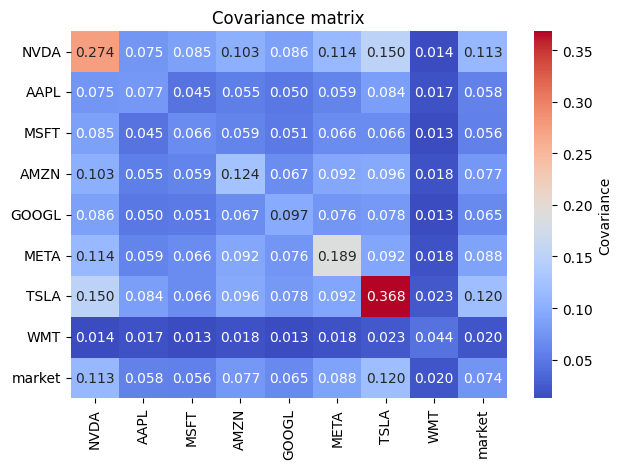

In [18]:
# For a better visualization
import seaborn as sns

# Display the heatmap
sns.heatmap(covariance_matrix, annot=True, fmt=".3f", cmap='coolwarm', cbar_kws={'label': 'Covariance'})
plt.title('Covariance matrix')
plt.tight_layout()
plt.show()

* **1.b/** Write a function returning, for a given range of dates, a vector of expected price returns. It may either be historical returns or forecast ones, using for example the CAPM, by the mean of a beta (cf TP2) and an input on the market expected return.

In [20]:
# We start with historical returns
def calc_average_returns(dataframe_returns, start_date, end_date):
    # Filter the dataset according to the dates
    dataframe_returns_filtered = dataframe_returns.loc[start_date:end_date]
    
    # Calculate the vector of average returns in this interval
    average_returns_df = pd.DataFrame(dataframe_returns_filtered.mean())
    average_returns_df.columns = ["Historical return"]
    
    return average_returns_df

average_returns = calc_average_returns(returns_df, '2012-01-01', '2025-12-31')
print(average_returns)


        Historical return
NVDA             0.002684
AAPL             0.000745
MSFT             0.000726
AMZN             0.000507
GOOGL            0.001163
META             0.001128
TSLA             0.001109
WMT              0.000834
market           0.001112


In [21]:
# Calculate the price return of the market
returns_df['market'] = returns_df.mean(axis=1)

# We now implement the beta method
def calc_CAPM_returns(dataframe_returns, start_date, end_date, market_expected_return):
    # Filter the dataset according to the dates
    dataframe_returns_filtered = dataframe_returns.loc[start_date:end_date]
    
    # Calculate the betas
    betas = []
    market_variance = dataframe_returns_filtered['market'].var()
    for ticker in dataframe_returns_filtered.columns:
        covariance = dataframe_returns_filtered[ticker].cov(dataframe_returns_filtered['market'])
        betas.append(covariance / market_variance)
            
    # Dataframe of expected returns
    expected_df = pd.DataFrame(betas, index=dataframe_returns_filtered.columns, columns=['CAPM return'])
    expected_df = expected_df * market_expected_return
    
    return expected_df

CAPM_returns = calc_CAPM_returns(returns_df, '2012-01-01', '2024-12-31', 0.01)
print(CAPM_returns)

        CAPM return
NVDA       0.015494
AAPL       0.007526
MSFT       0.007858
AMZN       0.010402
GOOGL      0.008826
META       0.012143
TSLA       0.015424
WMT        0.002327
market     0.010000


We would like to compare historically the expected return of a stock in the two approaches. The expected returns are computed using the last year of data. The expected return of the market in the CAPM approach will be its historical average return during the last year.

            Historical return  CAPM return
2022-01-31           0.004507     0.003369
2022-02-01           0.004507     0.003369
2022-02-02           0.004507     0.003369
2022-02-03           0.004507     0.003369
2022-02-04           0.004507     0.003369
...                       ...          ...
2026-01-23           0.004507     0.003369
2026-01-26           0.004507     0.003369
2026-01-27           0.004507     0.003369
2026-01-28           0.004507     0.003369
2026-01-29           0.004507     0.003369

[1003 rows x 2 columns]


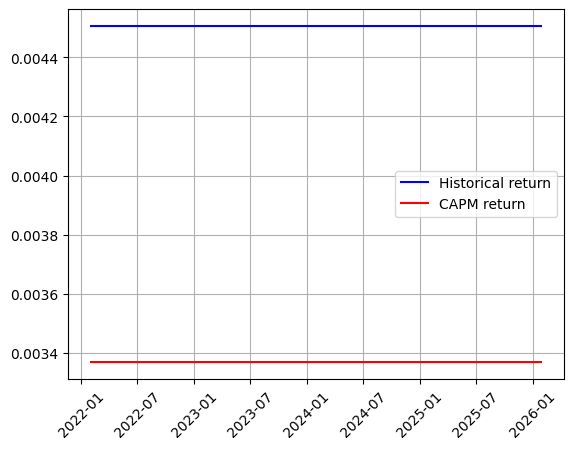

In [23]:
window_size = 252
historical_results = []
CAPM_results = []
stock = "NVDA"

for i in range(len(returns_df) - window_size + 1):
    start_date = "2023-12-31"
    end_date = "2024-12-31"
    
    # Calculate expected returns
    hist_returns_df = calc_average_returns(returns_df, start_date, end_date)
    stock_hist_return = hist_returns_df.loc[stock, "Historical return"]
    market_hist_return = hist_returns_df.loc["market", "Historical return"]
    CAPM_returns_df = calc_CAPM_returns(returns_df, start_date, end_date, market_hist_return)
    stock_CAPM_return = CAPM_returns_df.loc[stock, "CAPM return"]
    
    # Store these expectations
    historical_results.append(stock_hist_return)
    CAPM_results.append(stock_CAPM_return)

# Create a dataframe with the results
dates_window = returns_df.index[window_size-1:]
expected_returns_df = pd.DataFrame({
    'Historical return': historical_results,
    'CAPM return': CAPM_results
}, index=dates_window)

print(expected_returns_df)

plt.plot(expected_returns_df.index, expected_returns_df['Historical return'], label="Historical return", color='blue')
plt.plot(expected_returns_df.index, expected_returns_df['CAPM return'], label="CAPM return", color='red')
plt.grid(True)
plt.legend()
plt.xticks(rotation=45)
plt.show()

* **1.c/** Write a function returning, for a given covariance matrix and vector of expected returns, the vector of weights maximizing Markowitz utility function, with the risk aversion determined so as to have a sum of weights equal to 1.

        Historical return
NVDA             0.004507
AAPL             0.001164
MSFT             0.000562
AMZN             0.001615
GOOGL            0.001376
META             0.002255
TSLA             0.002709
WMT              0.002214
market           0.002050
        CAPM return
NVDA       0.003369
AAPL       0.001199
MSFT       0.001466
AMZN       0.002055
GOOGL      0.001714
META       0.002253
TSLA       0.003927
WMT        0.000420
market     0.002050
            NVDA      AAPL      MSFT      AMZN     GOOGL      META      TSLA  \
NVDA    0.281323  0.076930  0.087055  0.103966  0.088060  0.116759  0.146314   
AAPL    0.076930  0.069513  0.046819  0.052407  0.049350  0.058248  0.077550   
MSFT    0.087055  0.046819  0.067609  0.061645  0.055689  0.067721  0.064362   
AMZN    0.103966  0.052407  0.061645  0.125219  0.069145  0.093264  0.090780   
GOOGL   0.088060  0.049350  0.055689  0.069145  0.094431  0.081524  0.069756   
META    0.116759  0.058248  0.067721  0.093264  0.081524  0.

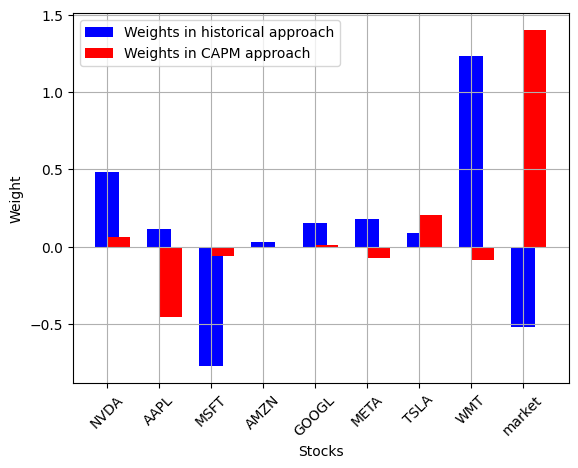

In [24]:
def markowitz_optimal_weights_sum1(cov_matrix_df, expected_returns_df):
    # Check that the DataFrame of expected returns only contains one column
    if expected_returns_df.shape[1] != 1:
        raise ValueError("The DataFrame of expected returns must contain exactly one column.")

    # Calculate the inverse of the covariance matrix
    cov_matrix_inv = np.linalg.inv(cov_matrix_df)

    # Calculate the matrix product Sigma^{-1} * mu
    sigma_inv_mu = cov_matrix_inv.dot(expected_returns_df)

    # Calculate lambda to have a sum of weights equal to 1
    lambda_value = sigma_inv_mu.sum()/2

    # Omega = Sigma^{-1} * mu / lambda
    optimal_weights = sigma_inv_mu / (2*lambda_value)

    # Create a DataFrame
    optimal_weights_df = pd.DataFrame(optimal_weights, columns=['Weight'], index=cov_matrix_df.index)

    return optimal_weights_df


# Application
start_date_risk = '2020-01-01'
start_date_performance = '2024-01-01'
end_date =  '2024-12-31'
historical_returns_df = calc_average_returns(returns_df, start_date_performance, end_date)
market_hist_return = historical_returns_df.loc['market', 'Historical return']
CAPM_returns_df = calc_CAPM_returns(returns_df, start_date_performance, end_date, market_hist_return)
covariance_matrix_df = calc_cov(returns_df, start_date_risk, end_date)

print(historical_returns_df)
print(CAPM_returns_df)
print(covariance_matrix_df)

# Optimal weights
optimal_weights_hist_df = markowitz_optimal_weights_sum1(covariance_matrix_df, historical_returns_df)
optimal_weights_hist_df.columns = ['Weight in historical approach']
optimal_weights_CAPM_df = markowitz_optimal_weights_sum1(covariance_matrix_df, CAPM_returns_df)
optimal_weights_CAPM_df.columns = ['Weight in CAPM approach']
optimal_weights_df = pd.concat([optimal_weights_hist_df, optimal_weights_CAPM_df], axis=1)
print(optimal_weights_df)

# Bar chart
bar_width = 0.45
stocks=optimal_weights_df.index
plt.bar(stocks, optimal_weights_df['Weight in historical approach'], bar_width, label='Weights in historical approach', color='b')
plt.bar(stocks, optimal_weights_df['Weight in CAPM approach'], bar_width, label='Weights in CAPM approach', color='r', align='edge') #align='edge' offsets the bar
plt.xticks(rotation=45)
plt.xlabel('Stocks')
plt.ylabel('Weight')
plt.legend()
plt.grid()
plt.show()

Some questions regarding the above results:
* Why does BNP.PA have a negative weight (historical approach) whereas its historical return is positive?
* What does happen for CAPM weights when the time interval used for computing the covariance matrix is the same as the one used for betas? Can you explain this mathematically?




*Questions 1.d and 1.e are optional and will not be corrected.*

* **1.d/** ($\star$) Write a function returning, for a given covariance matrix, a vector of expected returns, and a **target of risk**, the vector of weights maximizing the performance, without any other constraint.

* **1.e/** ($\star$) Write a function returning, for a given covariance matrix, a vector of expected returns, and a **target of performance**, the vector of weights minimizing the risk, with the following constraints: no short position and sum of weights equal to 1.





# Performance evaluation (Q2)

**Question 2:** In Question 1, we have created a portfolio for a given estimation set. We are now going to create a dynamic portfolio, without considering transaction costs: our estimation set is a sliding window. We will then evaluate the performance of this portfolio.

* **2.a/** For a fixed size of sliding estimation set, create a DataFrame containing the dynamic weights, for one of the portfolio selection methods defined in Question 1.

In [ ]:
window_size_performance = 252
window_size_risk = 1000 #>window_size_performance
historical_results = []
CAPM_results = []

#Initializing weights
dynamic_weights_hist_df = pd.DataFrame(index=returns_df.index[window_size_risk-1:], columns=returns_df.columns)
dynamic_weights_hist_df.drop(columns=['market'], inplace=True)
dynamic_weights_CAPM_df = pd.DataFrame(index=returns_df.index[window_size_risk-1:], columns=returns_df.columns)
dynamic_weights_CAPM_df.drop(columns=['market'], inplace=True)

for i in range(len(returns_df) - window_size_risk + 1):
    start_date_risk = returns_df.index[i]
    start_date_performance = returns_df.index[i + window_size_risk - window_size_performance]
    end_date = returns_df.index[i + window_size_risk - 1]

    #Calculate expected returns
    ...

    #Covariance matrix
    ...

    #Removing the market from the list of assets
    ...

    #Optimal weights
    ...

    #Dynamic weights
    dynamic_weights_hist_df.loc[end_date] = ...
    dynamic_weights_CAPM_df.loc[end_date] = ...

print(dynamic_weights_hist_df)
print(dynamic_weights_CAPM_df)

NameError: name 'pd' is not defined

In [ ]:
# Graph
for ticker in dynamic_weights_hist_df.columns:
    plt.plot(dynamic_weights_hist_df.index, dynamic_weights_hist_df[ticker], label=ticker)
plt.title("Time series of weights in the historical approach")
plt.ylabel("weight")
plt.ylim(-3, 3) #To truncate the y-axis
plt.grid(False)
plt.legend(bbox_to_anchor=(1, 1), ncol=2)
plt.show()

In [ ]:
# Graph for CAPM
for ticker in dynamic_weights_CAPM_df.columns:
    plt.plot(dynamic_weights_CAPM_df.index, dynamic_weights_CAPM_df[ticker], label=ticker)
plt.title("Time series of weights in the CAPM approach")
plt.ylabel("weight")
plt.grid(False)
plt.legend(bbox_to_anchor=(1, 1), ncol=2)
plt.show()

* **2.b/** Create a new DataFrame containing the value and returns of the dynamic portfolio.

In [ ]:
# We remove the first dates in the DataFrame of returns
returns_df_filtered = ...

# Calculate ptf returns
...

# Benchmark: market return
...

# Value of the portfolio
initial_value = 100
ptf_returns_df['CAPM ptf value'] = ...
ptf_returns_df['Historical-approach ptf value'] = ...
ptf_returns_df['Market ptf value'] = .

print(ptf_returns_df)
plt.plot(ptf_returns_df.index, ptf_returns_df['CAPM ptf value'], label="CAPM ptf value", color='blue')
plt.plot(ptf_returns_df.index, ptf_returns_df['Market ptf value'], label="Market ptf value", color='green')
#plt.plot(ptf_returns_df.index, ptf_returns_df['Historical-approach ptf value'], label="Historical-approach ptf value", color='red')
plt.legend()
plt.show()

* **2.c/** Determine the ex-post Sharpe ratio of your portfolio.

In [ ]:
#We write a function for calculating the Sharpe ratio from a dataframe of returns

def annualized_daily_sharpe_ratio(returns_df, risk_free_rate=0):
    ...

    return sharpe

returns_ptf_df = ptf_returns_df['Market return']
print(f"Sharpe ratio of the equally weighted portfolio (the market): {annualized_daily_sharpe_ratio(returns_ptf_df):.3f}.\n")
returns_ptf_df = ptf_returns_df['CAPM ptf return']
print(f"Sharpe ratio of the portfolio built using the CAPM approach: {annualized_daily_sharpe_ratio(returns_ptf_df):.3f}.\n")
returns_ptf_df = ptf_returns_df['Historical-approach ptf return']
print(f"Sharpe ratio of the portfolio built using the historical approach: {annualized_daily_sharpe_ratio(returns_ptf_df):.3f}.")

*Questions 2.d and 2.e are optional and will not be corrected.*

* **2.d/** ($\star$)  Compare to your ex-ante Sharpe ratio. Which one is the better?

* **2.e/** ($\star$) Write a function returning Sortino, Upside potential, and $\Omega(0)$ ratios and apply it to your ex-post performance.

* **2.f/** What is the maximum drawdown of your portfolio?

In [ ]:
# We write a function calculating the maximum drawdown from a data frame representing a time series of values of a protfolio

def maximum_drawdown(ptf_values_df):
    ...

    return max_drawdown

# Application
values_ptf_df = ptf_returns_df['Market ptf value']
print(f"Maximum drawdown of the equally weighted portfolio (the market): {100 * maximum_drawdown(values_ptf_df):.1f}%.\n")
values_ptf_df = ptf_returns_df['CAPM ptf value']
print(f"Maximum drawdown of the portfolio built using the CAPM approach: {100 * maximum_drawdown(values_ptf_df):.1f}%.\n")
values_ptf_df = ptf_returns_df['Historical-approach ptf value']
print(f"Maximum drawdown of the portfolio built using the historical approach: {100 * maximum_drawdown(values_ptf_df):.1f}%.")